# 2.5D Fusion V2

This notebook fuses the saved axial, coronal, and sagittal V2 flows into one 3D field and evaluates the fused warp.

In [1]:
import os
import sys
import json
import time
import importlib.util
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import torch
import torch.nn.functional as F
from IPython.display import display, Image

BASE_DIR = Path('.').resolve()
PYC_DIR = (BASE_DIR / '../__pycache__').resolve()
SEG_LABELS = [2, 3, 4, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28]
WINDOW_RADIUS = 3

DATA_ROOT = '../../Data/Tuco'
INPUT_DIR = './artifacts/results/train_2p5d_v2'
OUTPUT_DIR = './artifacts/results/fusion_2p5d_v2'
MAX_VAL = None
PAIR_LIMIT = None

SMOOTH_SIGMAS = [0.75, 1.0]

FUSION_WEIGHTS = {
    'axial_xy': 0.35,
    'coronal_x': 0.65,
    'sagittal_y': 0.65,
    'coronal_z': 0.50,
    'sagittal_z': 0.50,
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Input dir:', INPUT_DIR)
print('Output dir:', OUTPUT_DIR)
print('Fusion weights:', FUSION_WEIGHTS)
print('Smooth sigmas:', SMOOTH_SIGMAS)


Device: cuda
Input dir: ./artifacts/results/train_2p5d_v2
Output dir: ./artifacts/results/fusion_2p5d_v2
Fusion weights: {'axial_xy': 0.35, 'coronal_x': 0.65, 'sagittal_y': 0.65, 'coronal_z': 0.5, 'sagittal_z': 0.5}
Smooth sigmas: [0.75, 1.0]


In [2]:
import sys
from pathlib import Path

for _candidate in [Path.cwd().resolve(), Path.cwd().resolve().parent, Path.cwd().resolve() / 'Voxelmorph']:
    if (_candidate / 'tuco_dataset.py').exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break
else:
    raise FileNotFoundError('Could not find tuco_dataset.py from the current working directory')

from tuco_dataset import TucoDataset

def normalize_volume_contract(volume):
    arr = volume.astype(np.float32)
    arr_min = float(arr.min())
    arr_max = float(arr.max())
    if arr_max <= arr_min:
        return np.zeros_like(arr, dtype=np.float32)
    if arr_min >= -1.001 and arr_max <= 1.001:
        if arr_min >= -1e-4 and arr_max <= 1.0001:
            return (2.0 * arr - 1.0).astype(np.float32)
        return arr
    return (2.0 * (arr - arr_min) / (arr_max - arr_min) - 1.0).astype(np.float32)

def load_val_volumes(data_root, max_n=None):
    ds = TucoDataset(data_root, split='val')
    if max_n is not None:
        from torch.utils.data import Subset
        ds = Subset(ds, range(min(max_n, len(ds))))

    moving_vols, fixed_vols = [], []
    moving_segs, fixed_segs = [], []
    for sample in ds:
        moving_vols.append(normalize_volume_contract(sample['moving'].squeeze(0).numpy().astype(np.float32)))
        fixed_vols.append(normalize_volume_contract(sample['fixed'].squeeze(0).numpy().astype(np.float32)))
        moving_segs.append(sample['moving_seg'].squeeze(0).numpy().astype(np.int16))
        fixed_segs.append(sample['fixed_seg'].squeeze(0).numpy().astype(np.int16))
    return moving_vols, fixed_vols, moving_segs, fixed_segs

val_mr_vols, val_ct_vols, val_mr_segs, val_ct_segs = load_val_volumes(DATA_ROOT, MAX_VAL)
pair_rows = json.loads(Path(INPUT_DIR, 'summary.json').read_text())
pair_rows = [row for row in pair_rows if row['moving_idx'] < len(val_mr_vols) and row['fixed_idx'] < len(val_ct_vols)]
if PAIR_LIMIT is not None:
    pair_rows = pair_rows[:PAIR_LIMIT]

print('Validation volumes:', len(val_mr_vols))
print('Pairs to process:', [(row['pair_index'], row['moving_idx'], row['fixed_idx']) for row in pair_rows])


Found 18 volume pairs for split 'val'
Validation volumes: 18
Pairs to process: [(0, 11, 0), (1, 14, 5)]


In [3]:
def compute_dice_per_label(warped_seg, fixed_seg, labels=SEG_LABELS):
    scores = []
    for lbl in labels:
        w = (warped_seg == lbl).astype(np.float32)
        f = (fixed_seg == lbl).astype(np.float32)
        inter = float((w * f).sum())
        union = float(w.sum() + f.sum())
        scores.append(1.0 if union == 0.0 else 2.0 * inter / union)
    return np.array(scores, dtype=np.float32)


def mutual_information_np(a, b, bins=64, clip_range=(-1.0, 1.0)):
    hist_2d, _, _ = np.histogram2d(a.ravel(), b.ravel(), bins=bins, range=[clip_range, clip_range])
    pxy = hist_2d / np.maximum(hist_2d.sum(), 1.0)
    px = pxy.sum(axis=1, keepdims=True)
    py = pxy.sum(axis=0, keepdims=True)
    nz = pxy > 0
    return float((pxy[nz] * np.log(pxy[nz] / (px @ py)[nz])).sum())


def resize_flow_to_hw(flow_chw, target_hw):
    target_h, target_w = target_hw
    _, src_h, src_w = flow_chw.shape
    sx = target_w / float(src_w)
    sy = target_h / float(src_h)
    fx = cv2.resize(flow_chw[0], (target_w, target_h), interpolation=cv2.INTER_LINEAR) * sx
    fy = cv2.resize(flow_chw[1], (target_w, target_h), interpolation=cv2.INTER_LINEAR) * sy
    return np.stack([fx, fy]).astype(np.float32)


def lift_axial(flow_stack, vol_shape):
    d, h, w = vol_shape
    field = np.zeros((3, d, h, w), dtype=np.float32)
    n = flow_stack.shape[0]
    for z in range(d):
        src = min(max(z - WINDOW_RADIUS, 0), n - 1)
        flow = resize_flow_to_hw(flow_stack[src], (h, w))
        field[0, z] = flow[0]
        field[1, z] = flow[1]
    return field


def lift_coronal(flow_stack, vol_shape):
    d, h, w = vol_shape
    field = np.zeros((3, d, h, w), dtype=np.float32)
    n = flow_stack.shape[0]
    for y in range(h):
        src = min(max(y - WINDOW_RADIUS, 0), n - 1)
        flow = resize_flow_to_hw(flow_stack[src], (d, w))
        field[0, :, y, :] = flow[0]
        field[2, :, y, :] = flow[1]
    return field


def lift_sagittal(flow_stack, vol_shape):
    d, h, w = vol_shape
    field = np.zeros((3, d, h, w), dtype=np.float32)
    n = flow_stack.shape[0]
    for x in range(w):
        src = min(max(x - WINDOW_RADIUS, 0), n - 1)
        flow = resize_flow_to_hw(flow_stack[src], (d, h))
        field[1, :, :, x] = flow[0]
        field[2, :, :, x] = flow[1]
    return field


def fuse_fields(axial, coronal, sagittal):
    fused = np.zeros_like(axial)
    fused[0] = 0.5 * (axial[0] + coronal[0])
    fused[1] = 0.5 * (axial[1] + sagittal[1])
    fused[2] = 0.5 * (coronal[2] + sagittal[2])
    return fused


def fuse_fields_weighted(axial, coronal, sagittal, weights=FUSION_WEIGHTS):
    fused = np.zeros_like(axial)
    fused[0] = weights['axial_xy'] * axial[0] + weights['coronal_x'] * coronal[0]
    fused[1] = weights['axial_xy'] * axial[1] + weights['sagittal_y'] * sagittal[1]
    fused[2] = weights['coronal_z'] * coronal[2] + weights['sagittal_z'] * sagittal[2]
    return fused


def smooth_field_3d(field, sigma):
    out = np.zeros_like(field)
    for c in range(field.shape[0]):
        out[c] = gaussian_filter(field[c], sigma=sigma).astype(np.float32)
    return out


def warp_volume_3d(volume, flow, mode='bilinear'):
    src = torch.from_numpy(volume[None, None].astype(np.float32)).to(device)
    flow_t = torch.from_numpy(flow[None].astype(np.float32)).to(device)
    _, _, d, h, w = src.shape
    zz, yy, xx = torch.meshgrid(
        torch.arange(d, device=device),
        torch.arange(h, device=device),
        torch.arange(w, device=device),
        indexing='ij',
    )
    grid_x = xx.float().unsqueeze(0) + flow_t[:, 0]
    grid_y = yy.float().unsqueeze(0) + flow_t[:, 1]
    grid_z = zz.float().unsqueeze(0) + flow_t[:, 2]
    grid = torch.stack([
        2.0 * grid_x / max(w - 1, 1) - 1.0,
        2.0 * grid_y / max(h - 1, 1) - 1.0,
        2.0 * grid_z / max(d - 1, 1) - 1.0,
    ], dim=-1)
    warped = F.grid_sample(src, grid, align_corners=True, padding_mode='border', mode=mode)
    return warped[0, 0].detach().cpu().numpy()


def summarize_registration(moving_vol, fixed_vol, moving_seg, fixed_seg, flow, warped_vol, warped_seg):
    dice_before = compute_dice_per_label(moving_seg, fixed_seg)
    dice_after = compute_dice_per_label(warped_seg, fixed_seg)
    return {
        'mi_before': mutual_information_np(moving_vol, fixed_vol),
        'mi_after': mutual_information_np(warped_vol, fixed_vol),
        'dice_before': float(dice_before.mean()),
        'dice_after': float(dice_after.mean()),
        'flow_min': float(flow.min()),
        'flow_max': float(flow.max()),
        'flow_mean': float(flow.mean()),
        'flow_std': float(flow.std()),
    }


def save_preview(path, moving, fixed, warped, flow, label='fused'):
    mag = np.sqrt((flow ** 2).sum(axis=0))
    z = moving.shape[0] // 2
    y = moving.shape[1] // 2
    x = moving.shape[2] // 2
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    planes = [
        ('axial', moving[z], fixed[z], warped[z], mag[z]),
        ('coronal', moving[:, y, :], fixed[:, y, :], warped[:, y, :], mag[:, y, :]),
        ('sagittal', moving[:, :, x], fixed[:, :, x], warped[:, :, x], mag[:, :, x]),
    ]
    for row, (name, mov, fix, wrp, mag_plane) in enumerate(planes):
        axes[row, 0].imshow(mov, cmap='gray')
        axes[row, 0].set_title(f'{name} moving')
        axes[row, 1].imshow(fix, cmap='gray')
        axes[row, 1].set_title(f'{name} fixed')
        axes[row, 2].imshow(wrp, cmap='gray')
        axes[row, 2].set_title(f'{name} {label} warped')
        axes[row, 3].imshow(mag_plane, cmap='magma')
        axes[row, 3].set_title(f'{name} |flow|')
        for col in range(4):
            axes[row, col].axis('off')
    plt.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)


In [4]:
all_results = []
for row in pair_rows:
    pair_idx = row['pair_index']
    moving_idx = row['moving_idx']
    fixed_idx = row['fixed_idx']
    pair_name = f'pair_{pair_idx:02d}_m{moving_idx:03d}_f{fixed_idx:03d}'
    pair_input_dir = Path(INPUT_DIR) / pair_name
    pair_output_dir = Path(OUTPUT_DIR) / pair_name
    pair_output_dir.mkdir(parents=True, exist_ok=True)

    moving_vol = val_mr_vols[moving_idx]
    fixed_vol = val_ct_vols[fixed_idx]
    moving_seg = val_mr_segs[moving_idx]
    fixed_seg = val_ct_segs[fixed_idx]
    vol_shape = moving_vol.shape

    axial_flow = np.load(pair_input_dir / 'axial' / 'flow_stack.npy').astype(np.float32)
    coronal_flow = np.load(pair_input_dir / 'coronal' / 'flow_stack.npy').astype(np.float32)
    sagittal_flow = np.load(pair_input_dir / 'sagittal' / 'flow_stack.npy').astype(np.float32)

    axial_field = lift_axial(axial_flow, vol_shape)
    coronal_field = lift_coronal(coronal_flow, vol_shape)
    sagittal_field = lift_sagittal(sagittal_flow, vol_shape)
    mean_fused_field = fuse_fields(axial_field, coronal_field, sagittal_field)
    weighted_fused_field = fuse_fields_weighted(axial_field, coronal_field, sagittal_field)
    smoothed_fields = {sigma: smooth_field_3d(mean_fused_field, sigma) for sigma in SMOOTH_SIGMAS}

    t0 = time.perf_counter()
    axial_warped = warp_volume_3d(moving_vol, axial_field, mode='bilinear')
    coronal_warped = warp_volume_3d(moving_vol, coronal_field, mode='bilinear')
    sagittal_warped = warp_volume_3d(moving_vol, sagittal_field, mode='bilinear')
    mean_fused_warped = warp_volume_3d(moving_vol, mean_fused_field, mode='bilinear')
    weighted_fused_warped = warp_volume_3d(moving_vol, weighted_fused_field, mode='bilinear')
    smoothed_warped = {sigma: warp_volume_3d(moving_vol, smoothed_fields[sigma], mode='bilinear') for sigma in SMOOTH_SIGMAS}

    axial_seg = warp_volume_3d(moving_seg.astype(np.float32), axial_field, mode='nearest').astype(np.int16)
    coronal_seg = warp_volume_3d(moving_seg.astype(np.float32), coronal_field, mode='nearest').astype(np.int16)
    sagittal_seg = warp_volume_3d(moving_seg.astype(np.float32), sagittal_field, mode='nearest').astype(np.int16)
    mean_fused_seg = warp_volume_3d(moving_seg.astype(np.float32), mean_fused_field, mode='nearest').astype(np.int16)
    weighted_fused_seg = warp_volume_3d(moving_seg.astype(np.float32), weighted_fused_field, mode='nearest').astype(np.int16)
    smoothed_seg = {sigma: warp_volume_3d(moving_seg.astype(np.float32), smoothed_fields[sigma], mode='nearest').astype(np.int16) for sigma in SMOOTH_SIGMAS}
    elapsed_ms = (time.perf_counter() - t0) * 1000.0

    summary = {
        'pair_index': pair_idx,
        'moving_idx': moving_idx,
        'fixed_idx': fixed_idx,
        'fusion_method_mean': 'component mean across orientations',
        'fusion_method_weighted': 'fixed weighted component fusion',
        'fusion_weights': dict(FUSION_WEIGHTS),
        'smooth_sigmas': list(SMOOTH_SIGMAS),
        'fuse_runtime_ms': float(elapsed_ms),
        'axial_volume_metrics': summarize_registration(moving_vol, fixed_vol, moving_seg, fixed_seg, axial_field, axial_warped, axial_seg),
        'coronal_volume_metrics': summarize_registration(moving_vol, fixed_vol, moving_seg, fixed_seg, coronal_field, coronal_warped, coronal_seg),
        'sagittal_volume_metrics': summarize_registration(moving_vol, fixed_vol, moving_seg, fixed_seg, sagittal_field, sagittal_warped, sagittal_seg),
        'mean_fused_volume_metrics': summarize_registration(moving_vol, fixed_vol, moving_seg, fixed_seg, mean_fused_field, mean_fused_warped, mean_fused_seg),
        'weighted_fused_volume_metrics': summarize_registration(moving_vol, fixed_vol, moving_seg, fixed_seg, weighted_fused_field, weighted_fused_warped, weighted_fused_seg),
        'smoothed_volume_metrics': {},
    }

    np.save(pair_output_dir / 'mean_fused_flow.npy', mean_fused_field)
    np.save(pair_output_dir / 'mean_warped_volume.npy', mean_fused_warped)
    np.save(pair_output_dir / 'mean_warped_seg.npy', mean_fused_seg)
    np.save(pair_output_dir / 'weighted_fused_flow.npy', weighted_fused_field)
    np.save(pair_output_dir / 'weighted_warped_volume.npy', weighted_fused_warped)
    np.save(pair_output_dir / 'weighted_warped_seg.npy', weighted_fused_seg)

    for sigma in SMOOTH_SIGMAS:
        sigma_tag = str(sigma).replace('.', 'p')
        summary['smoothed_volume_metrics'][sigma_tag] = summarize_registration(
            moving_vol, fixed_vol, moving_seg, fixed_seg, smoothed_fields[sigma], smoothed_warped[sigma], smoothed_seg[sigma]
        )
        np.save(pair_output_dir / f'smoothed_{sigma_tag}_flow.npy', smoothed_fields[sigma])
        np.save(pair_output_dir / f'smoothed_{sigma_tag}_warped_volume.npy', smoothed_warped[sigma])
        np.save(pair_output_dir / f'smoothed_{sigma_tag}_warped_seg.npy', smoothed_seg[sigma])
        save_preview(
            pair_output_dir / f'smoothed_{sigma_tag}_preview.png',
            moving_vol,
            fixed_vol,
            smoothed_warped[sigma],
            smoothed_fields[sigma],
            label=f'smoothed {sigma}'
        )

    with open(pair_output_dir / 'summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    save_preview(pair_output_dir / 'mean_preview.png', moving_vol, fixed_vol, mean_fused_warped, mean_fused_field, label='mean')
    save_preview(pair_output_dir / 'weighted_preview.png', moving_vol, fixed_vol, weighted_fused_warped, weighted_fused_field, label='weighted')

    best_smoothed = max(
        ((sigma, summary['smoothed_volume_metrics'][str(sigma).replace('.', 'p')]['dice_after']) for sigma in SMOOTH_SIGMAS),
        key=lambda x: x[1]
    )
    print(
        f"{pair_name}: mean dice {summary['mean_fused_volume_metrics']['dice_before']:.4f} -> {summary['mean_fused_volume_metrics']['dice_after']:.4f}, "
        f"weighted dice {summary['weighted_fused_volume_metrics']['dice_after']:.4f}, "
        f"best smoothed sigma={best_smoothed[0]} dice={best_smoothed[1]:.4f}"
    )
    all_results.append(summary)

aggregate = {}
base_keys = ['axial_volume_metrics', 'coronal_volume_metrics', 'sagittal_volume_metrics', 'mean_fused_volume_metrics', 'weighted_fused_volume_metrics']
for key in base_keys:
    aggregate[key] = {
        'dice_after_mean': float(np.mean([row[key]['dice_after'] for row in all_results])),
        'mi_after_mean': float(np.mean([row[key]['mi_after'] for row in all_results])),
        'flow_std_mean': float(np.mean([row[key]['flow_std'] for row in all_results])),
    }
for sigma in SMOOTH_SIGMAS:
    sigma_tag = str(sigma).replace('.', 'p')
    aggregate[f'smoothed_{sigma_tag}_volume_metrics'] = {
        'dice_after_mean': float(np.mean([row['smoothed_volume_metrics'][sigma_tag]['dice_after'] for row in all_results])),
        'mi_after_mean': float(np.mean([row['smoothed_volume_metrics'][sigma_tag]['mi_after'] for row in all_results])),
        'flow_std_mean': float(np.mean([row['smoothed_volume_metrics'][sigma_tag]['flow_std'] for row in all_results])),
    }

best_single_dice = max(
    aggregate['axial_volume_metrics']['dice_after_mean'],
    aggregate['coronal_volume_metrics']['dice_after_mean'],
    aggregate['sagittal_volume_metrics']['dice_after_mean'],
)
aggregate_compare = {
    'mean_minus_best_single_dice': float(aggregate['mean_fused_volume_metrics']['dice_after_mean'] - best_single_dice),
    'weighted_minus_best_single_dice': float(aggregate['weighted_fused_volume_metrics']['dice_after_mean'] - best_single_dice),
    'weighted_minus_mean_dice': float(aggregate['weighted_fused_volume_metrics']['dice_after_mean'] - aggregate['mean_fused_volume_metrics']['dice_after_mean']),
    'weighted_minus_mean_mi': float(aggregate['weighted_fused_volume_metrics']['mi_after_mean'] - aggregate['mean_fused_volume_metrics']['mi_after_mean']),
}
for sigma in SMOOTH_SIGMAS:
    sigma_tag = str(sigma).replace('.', 'p')
    aggregate_compare[f'smoothed_{sigma_tag}_minus_best_single_dice'] = float(
        aggregate[f'smoothed_{sigma_tag}_volume_metrics']['dice_after_mean'] - best_single_dice
    )
    aggregate_compare[f'smoothed_{sigma_tag}_minus_mean_dice'] = float(
        aggregate[f'smoothed_{sigma_tag}_volume_metrics']['dice_after_mean'] - aggregate['mean_fused_volume_metrics']['dice_after_mean']
    )
    aggregate_compare[f'smoothed_{sigma_tag}_minus_mean_mi'] = float(
        aggregate[f'smoothed_{sigma_tag}_volume_metrics']['mi_after_mean'] - aggregate['mean_fused_volume_metrics']['mi_after_mean']
    )

with open(Path(OUTPUT_DIR) / 'summary.json', 'w') as f:
    json.dump(all_results, f, indent=2)
with open(Path(OUTPUT_DIR) / 'aggregate.json', 'w') as f:
    json.dump(aggregate, f, indent=2)
with open(Path(OUTPUT_DIR) / 'aggregate_compare.json', 'w') as f:
    json.dump(aggregate_compare, f, indent=2)

aggregate, aggregate_compare


pair_00_m011_f000: mean dice 0.5674 -> 0.7480, weighted dice 0.7488, best smoothed sigma=1.0 dice=0.7492
pair_01_m014_f005: mean dice 0.6647 -> 0.7797, weighted dice 0.7791, best smoothed sigma=0.75 dice=0.7796


({'axial_volume_metrics': {'dice_after_mean': 0.736696869134903,
   'mi_after_mean': 0.6213952117908956,
   'flow_std_mean': 0.8994351029396057},
  'coronal_volume_metrics': {'dice_after_mean': 0.7354593873023987,
   'mi_after_mean': 0.6202078492640897,
   'flow_std_mean': 0.8344917297363281},
  'sagittal_volume_metrics': {'dice_after_mean': 0.728312611579895,
   'mi_after_mean': 0.6198587638189273,
   'flow_std_mean': 0.8381300270557404},
  'mean_fused_volume_metrics': {'dice_after_mean': 0.7638193368911743,
   'mi_after_mean': 0.6180671337700615,
   'flow_std_mean': 0.9328260123729706},
  'weighted_fused_volume_metrics': {'dice_after_mean': 0.7639316022396088,
   'mi_after_mean': 0.6176191019990162,
   'flow_std_mean': 0.9366685450077057},
  'smoothed_0p75_volume_metrics': {'dice_after_mean': 0.7643631994724274,
   'mi_after_mean': 0.6187302004922416,
   'flow_std_mean': 0.9019386470317841},
  'smoothed_1p0_volume_metrics': {'dice_after_mean': 0.7642501592636108,
   'mi_after_mean': 

{
  "axial_volume_metrics": {
    "dice_after_mean": 0.736696869134903,
    "mi_after_mean": 0.6213952117908956,
    "flow_std_mean": 0.8994351029396057
  },
  "coronal_volume_metrics": {
    "dice_after_mean": 0.7354593873023987,
    "mi_after_mean": 0.6202078492640897,
    "flow_std_mean": 0.8344917297363281
  },
  "sagittal_volume_metrics": {
    "dice_after_mean": 0.728312611579895,
    "mi_after_mean": 0.6198587638189273,
    "flow_std_mean": 0.8381300270557404
  },
  "mean_fused_volume_metrics": {
    "dice_after_mean": 0.7638193368911743,
    "mi_after_mean": 0.6180671337700615,
    "flow_std_mean": 0.9328260123729706
  },
  "weighted_fused_volume_metrics": {
    "dice_after_mean": 0.7639316022396088,
    "mi_after_mean": 0.6176191019990162,
    "flow_std_mean": 0.9366685450077057
  },
  "smoothed_0p75_volume_metrics": {
    "dice_after_mean": 0.7643631994724274,
    "mi_after_mean": 0.6187302004922416,
    "flow_std_mean": 0.9019386470317841
  },
  "smoothed_1p0_volume_metrics"

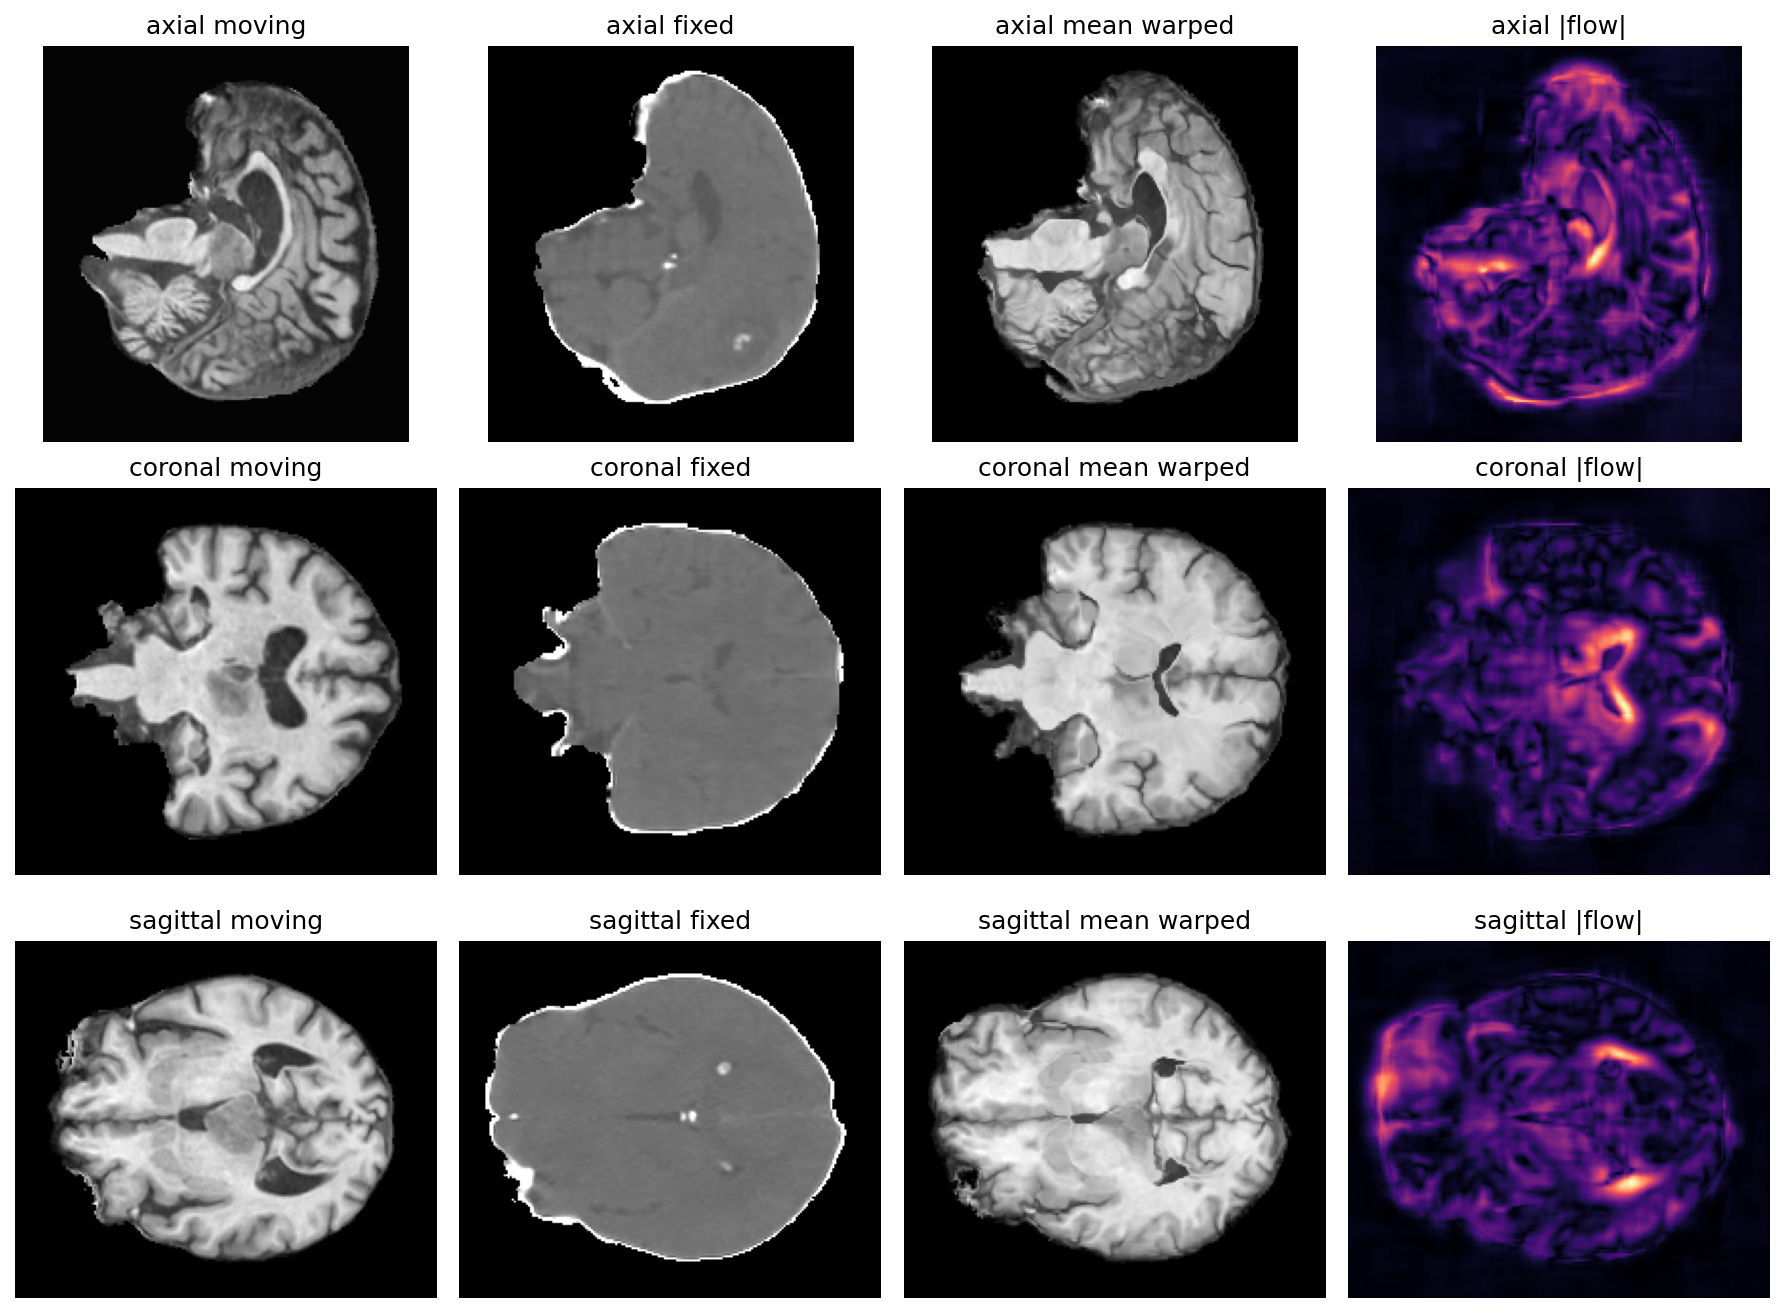

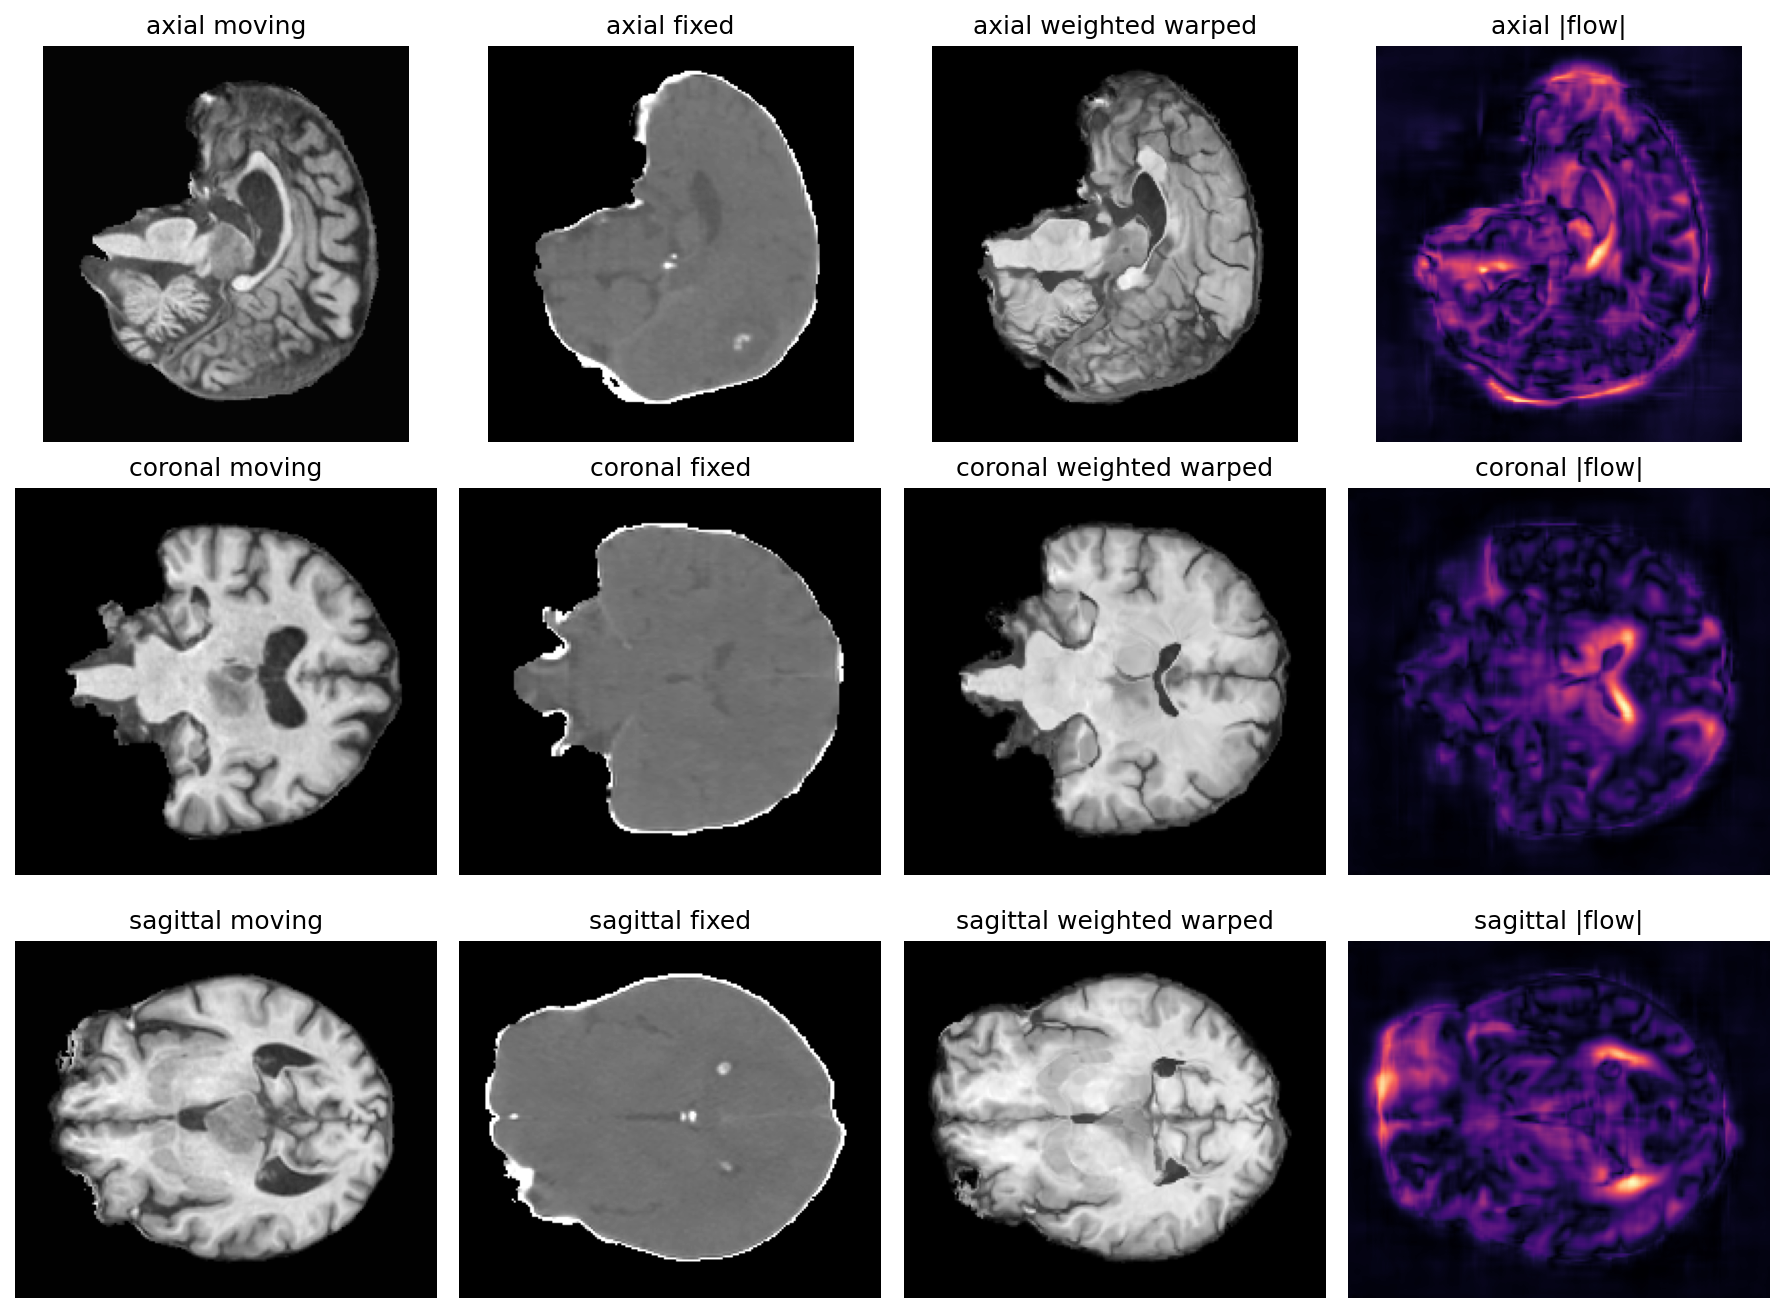

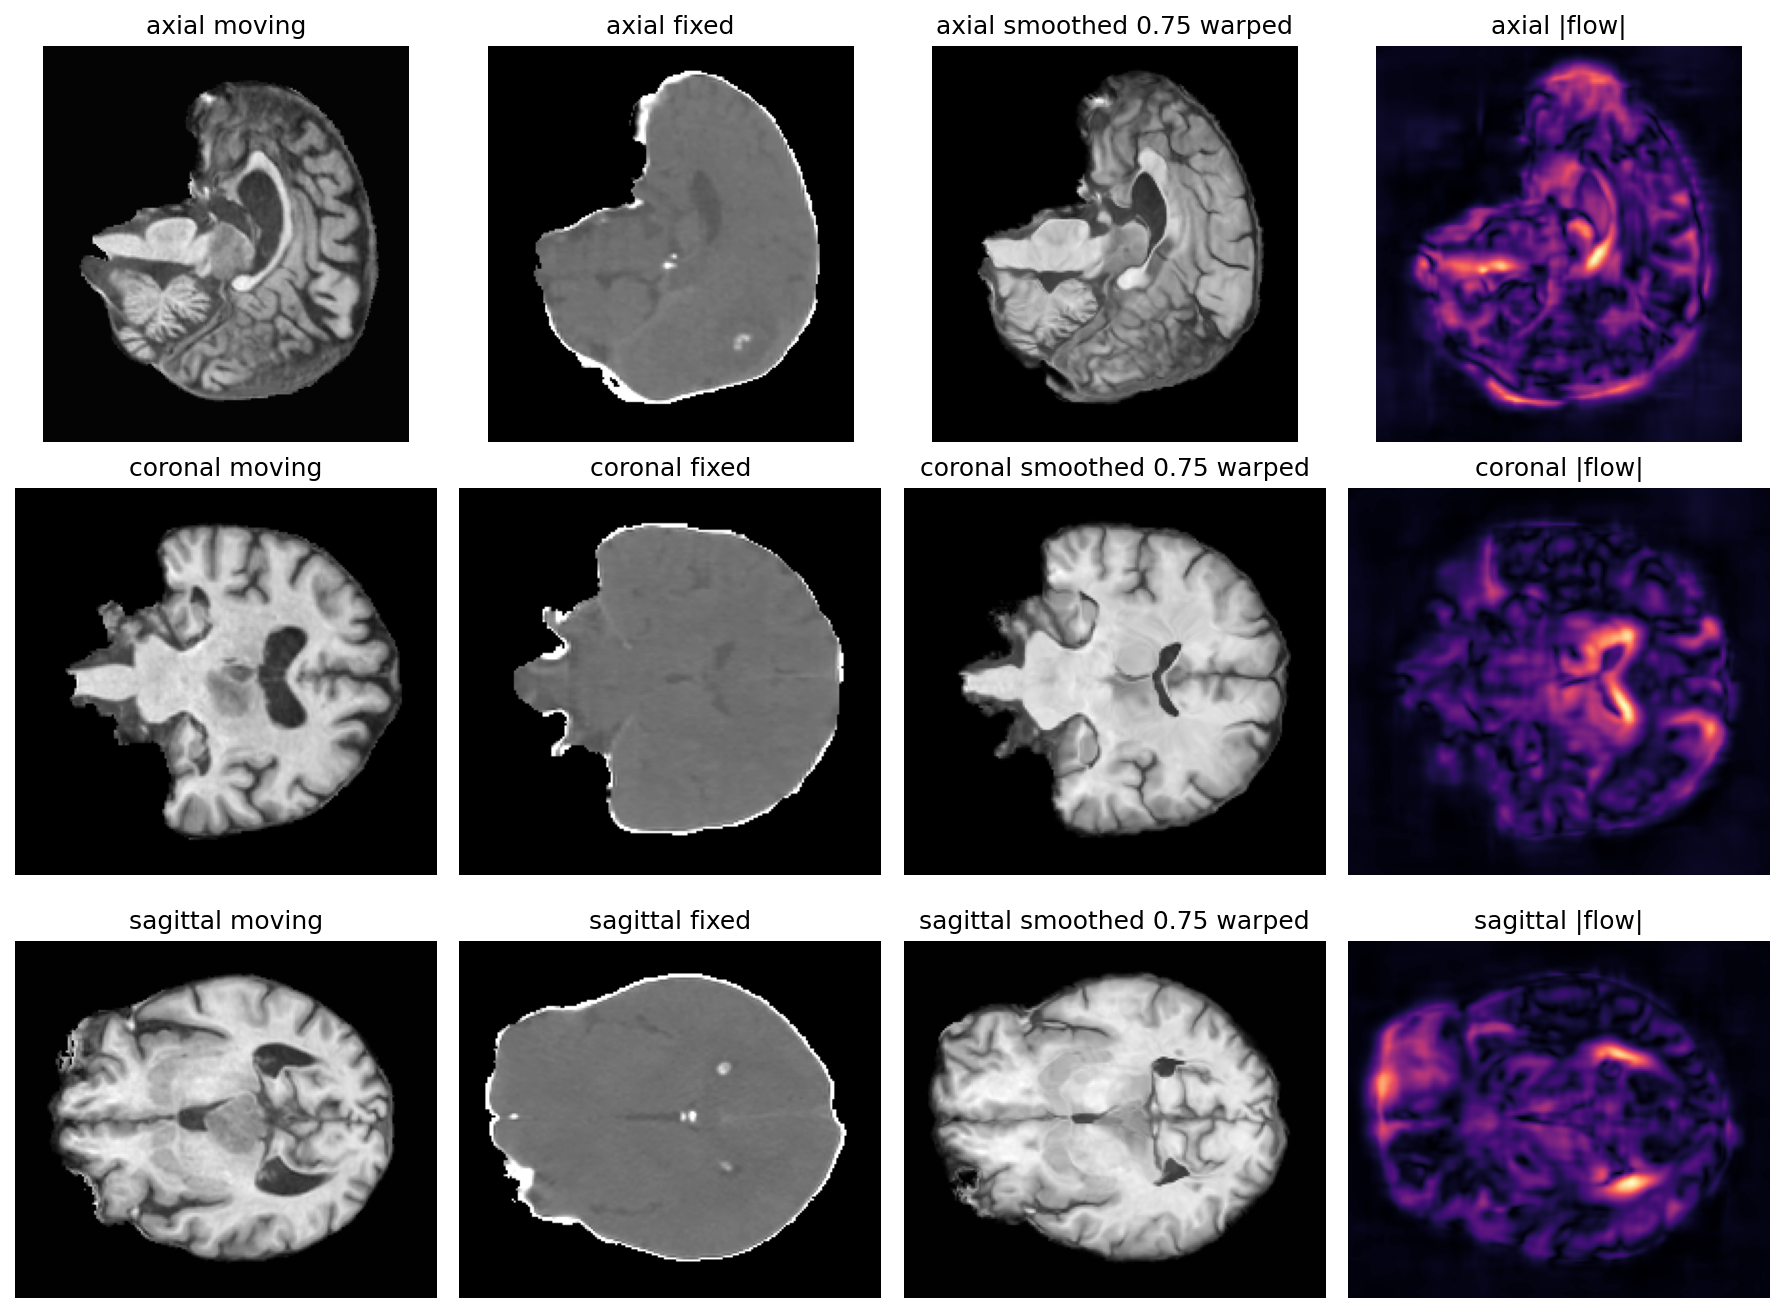

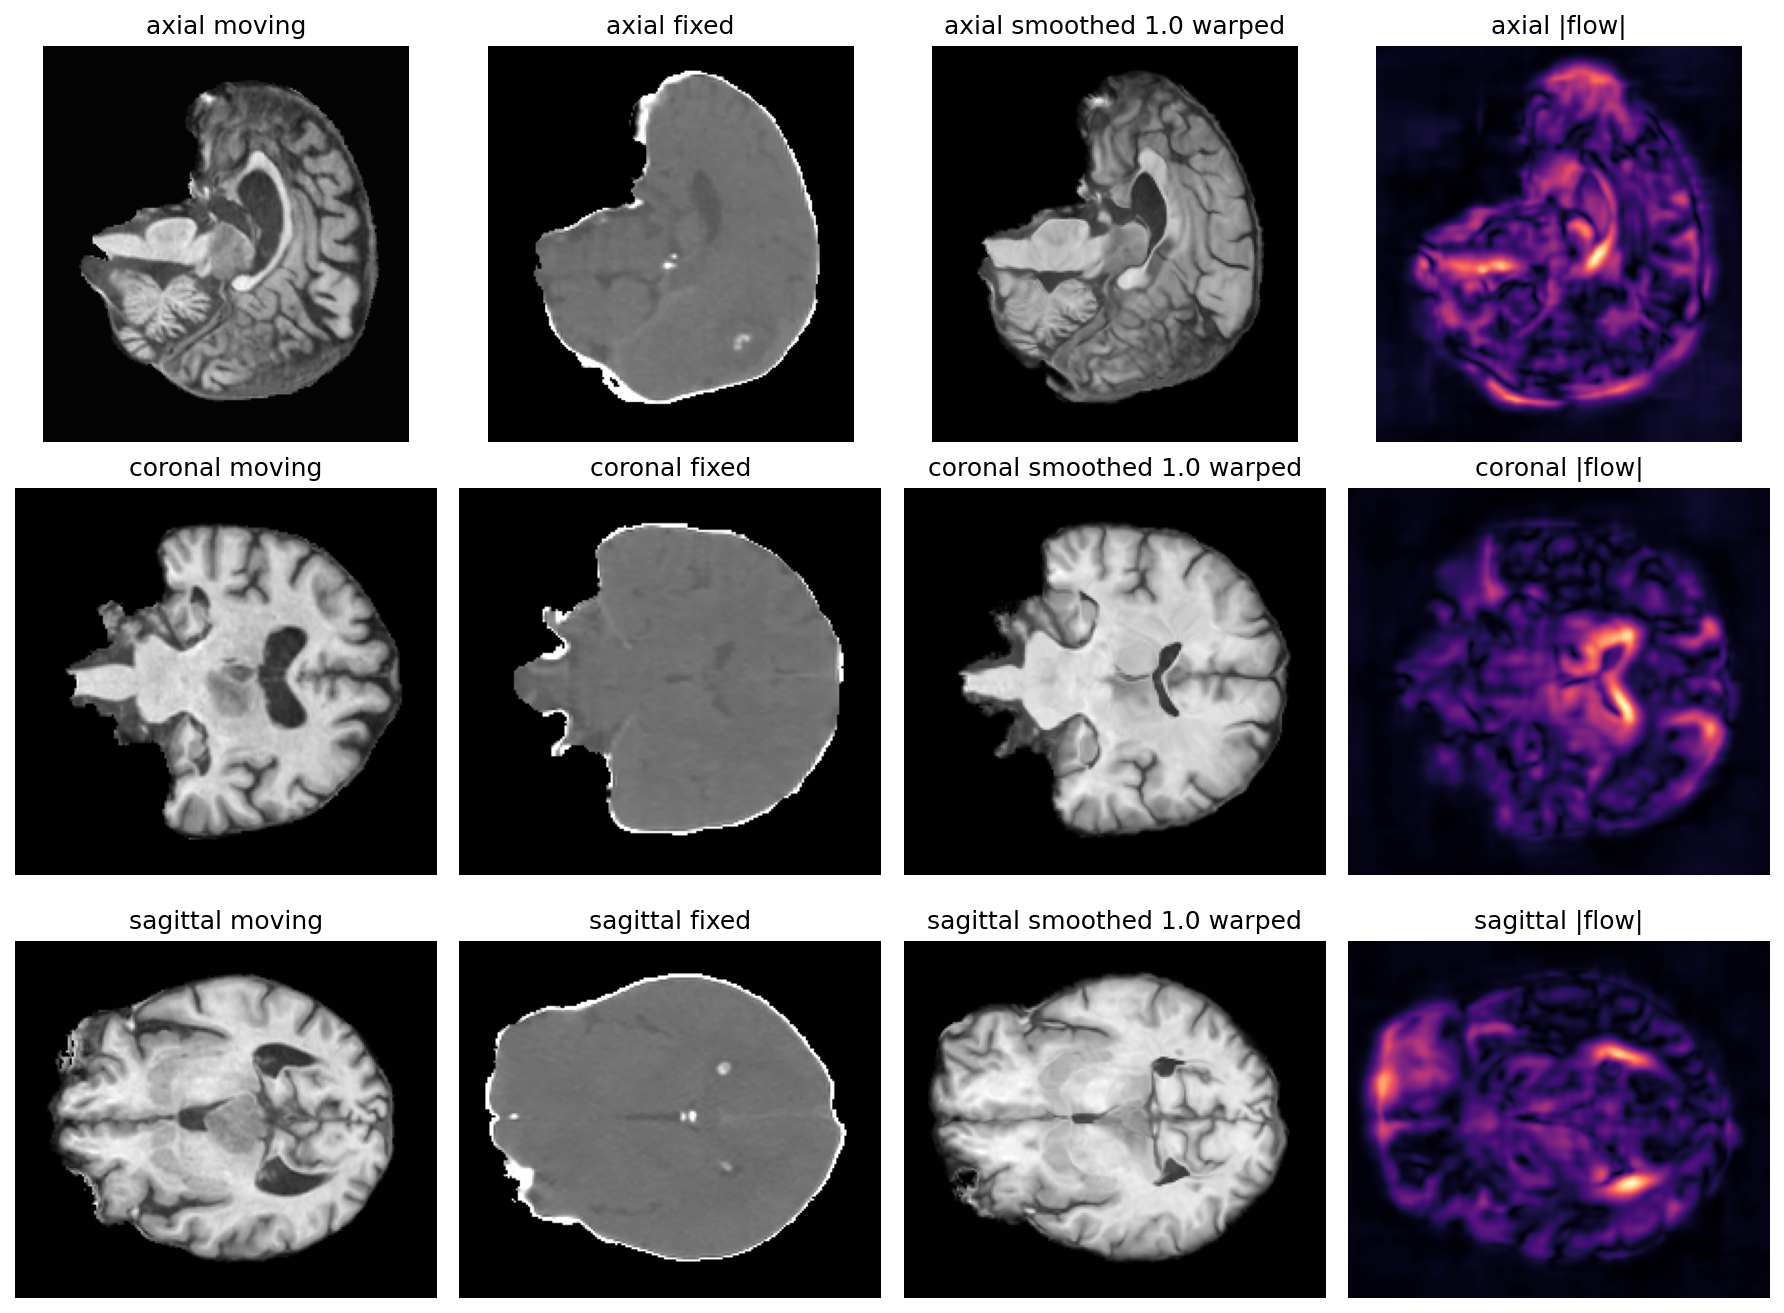

In [5]:
print(Path(OUTPUT_DIR, 'aggregate.json').read_text())
print(Path(OUTPUT_DIR, 'aggregate_compare.json').read_text())

comparison_rows = []
for key, label in [
    ('axial_volume_metrics', 'axial'),
    ('coronal_volume_metrics', 'coronal'),
    ('sagittal_volume_metrics', 'sagittal'),
    ('mean_fused_volume_metrics', 'mean_fused'),
    ('weighted_fused_volume_metrics', 'weighted_fused'),
    ('smoothed_0p75_volume_metrics', 'smoothed_0.75'),
    ('smoothed_1p0_volume_metrics', 'smoothed_1.0'),
]:
    if key in aggregate:
        comparison_rows.append({
            'name': label,
            'dice_after_mean': round(aggregate[key]['dice_after_mean'], 4),
            'mi_after_mean': round(aggregate[key]['mi_after_mean'], 4),
            'flow_std_mean': round(aggregate[key]['flow_std_mean'], 4),
        })
comparison_rows

if all_results:
    first = all_results[0]
    pair_name = f"pair_{first['pair_index']:02d}_m{first['moving_idx']:03d}_f{first['fixed_idx']:03d}"
    mean_preview_path = Path(OUTPUT_DIR) / pair_name / 'mean_preview.png'
    weighted_preview_path = Path(OUTPUT_DIR) / pair_name / 'weighted_preview.png'
    smoothed_075_preview_path = Path(OUTPUT_DIR) / pair_name / 'smoothed_0p75_preview.png'
    smoothed_10_preview_path = Path(OUTPUT_DIR) / pair_name / 'smoothed_1p0_preview.png'
    display(Image(filename=str(mean_preview_path)))
    display(Image(filename=str(weighted_preview_path)))
    if smoothed_075_preview_path.exists():
        display(Image(filename=str(smoothed_075_preview_path)))
    if smoothed_10_preview_path.exists():
        display(Image(filename=str(smoothed_10_preview_path)))
